# FIFA Player Statistics Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: 16,155 football players from the FIFA game — age, overall rating, value, wage, position and nationality. This notebook covers the data overview — shape, types, missing values, and the univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (16155, 81)


,Unnamed: 0,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,27,1987-06-24,169,67,Argentina,...,76,NaN,25,21,20,6,11,15,14,8
1,1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,29,1985-02-05,185,80,Portugal,...,85,NaN,22,31,23,7,11,15,14,11
2,2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,30,1984-01-23,180,80,Netherlands,...,80,NaN,29,26,26,10,8,11,5,15
3,3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,32,1981-10-03,195,95,Sweden,...,91,NaN,25,41,27,13,15,10,9,12
4,4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Neuer,28,1986-03-27,193,92,Germany,...,37,NaN,25,25,25,87,85,92,90,86


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('int64'): 45, dtype('O'): 18, dtype('float64'): 18}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16155 entries, 0 to 16154
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  16155 non-null  int64  
 1   sofifa_id                   16155 non-null  int64  
 2   player_url                  16155 non-null  object 
 3   short_name                  16155 non-null  object 
 4   long_name                   16155 non-null  object 
 5   age                         16155 non-null  int64  
 6   dob                         16155 non-null  object 
 7   height_cm                   16155 non-null  int64  
 8   weight_kg                   16155 non-null  int64  
 9   nationality                 16155 non-null  object 
 10  club_name                   15916 non-null  object 
 11  league_name                 15916 non-null  object 
 12  league_rank                 1

## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 26
                      missing     pct
mentality_composure     16155  100.00
release_clause_eur      16155  100.00
loaned_from             15243   94.35
nation_position         15074   93.31
nation_jersey_number    15074   93.31
player_tags             14919   92.35
gk_positioning          14380   89.01
gk_speed                14380   89.01
gk_reflexes             14380   89.01
gk_kicking              14380   89.01


## 3. Numeric distributions

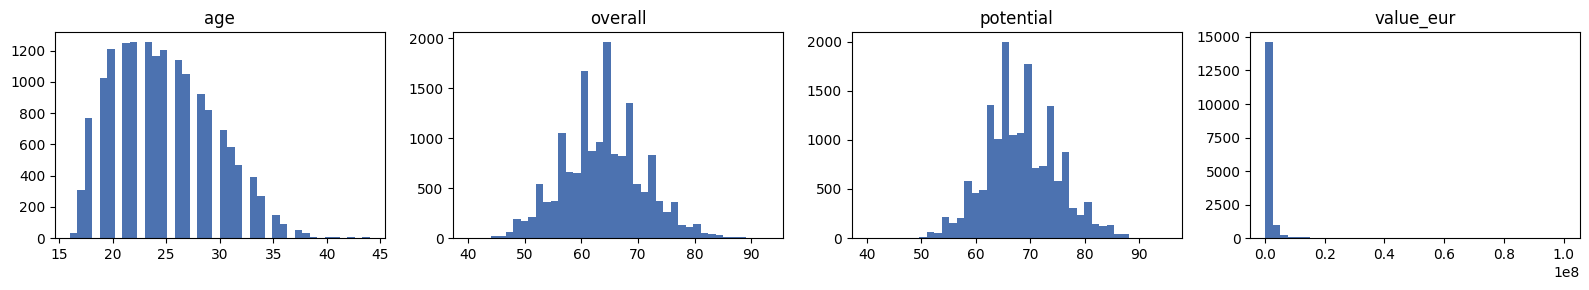

,age,overall,potential,value_eur
count,16155.00,16155.00,16155.00,1.615500e+04
mean,24.78,63.83,68.35,1.060882e+06
std,4.63,7.17,6.58,2.819128e+06
min,16.00,40.00,40.00,0.000000e+00
25%,21.00,59.00,64.00,1.200000e+05
50%,24.00,64.00,68.00,3.500000e+05
75%,28.00,68.00,73.00,8.250000e+05
max,44.00,93.00,95.00,1.005000e+08


In [4]:
num=['age', 'overall', 'potential', 'value_eur']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

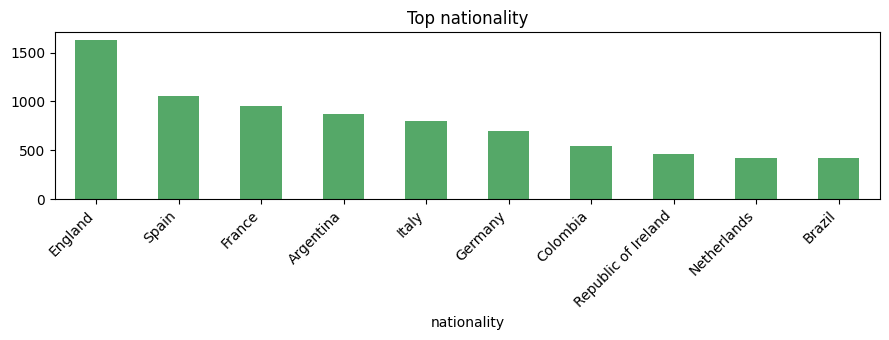

nationality
England                1627
Spain                  1051
France                  958
Argentina               867
Italy                   795
Germany                 701
Colombia                543
Republic of Ireland     460
Netherlands             419
Brazil                  416


In [5]:
vc=utils.top_counts(df['nationality'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top nationality'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above (size, missingness, distributions, dominant categories) frames the domain questions answered in notebook **02 — Analysis**, where the real insights and headline numbers (reported in the README) come from.